# Power Method for Finding the Dominant Eigenvector and Eigenvalue

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Example: 

$A = \begin{bmatrix} 2 & -4 \\ -1 & -1 \end{bmatrix}$ has eigenvalues $-2,3$, and the dominant eigenvector (corresponding to $\lambda = 3$) is $\vec{v} = \begin{bmatrix}4\\-1\end{bmatrix}$

Let's find it with the power method:

In [2]:
A = np.array([[2,-4],
              [-1,-1]])  # eigenvalues -2,3 

v = np.array([4,-1]) # eigenvector corresponding to eigenvalue 3

# normalize the eigenvector
unit_v = v/np.sqrt(np.dot(v,v))
print(unit_v)

[ 0.9701425  -0.24253563]


In [3]:
x0 = np.array([1,0])
vec_list = [x0] # eigenvector approximation list
eva_list = [np.dot(A@x0,x0)]  # eigenvalue approximation list

for i in range(1,16):
    new_vec = A@vec_list[i-1]
    vec_list.append(new_vec/np.sqrt(np.dot(new_vec,new_vec)))
    eva_list.append(np.dot(A@vec_list[-1],vec_list[-1]))
                   
vec_list                 

[array([1, 0]),
 array([ 0.89442719, -0.4472136 ]),
 array([ 0.99227788, -0.12403473]),
 array([ 0.94385836, -0.33035042]),
 array([ 0.98221192, -0.18777581]),
 array([ 0.95977097, -0.28078406]),
 array([ 0.97599402, -0.21779732]),
 array([ 0.96577783, -0.25937073]),
 array([ 0.97284362, -0.23146336]),
 array([ 0.96824978, -0.24998471]),
 array([ 0.97136321, -0.23759949]),
 array([ 0.96931049, -0.24583972]),
 array([ 0.97068906, -0.24033881]),
 array([ 0.96977453, -0.2440028 ]),
 array([ 0.97038621, -0.24155868]),
 array([ 0.96997931, -0.24318744])]

In [4]:
eva_list

[2,
 3.4,
 2.5692307692307694,
 3.2316258351893095,
 2.816398915084498,
 3.110922880450364,
 2.9205374022874464,
 3.050652979951641,
 2.9651624061775217,
 3.022761155612696,
 2.984616450758172,
 3.01016358936586,
 2.993183048364302,
 3.0045263975976515,
 2.9969742710638316,
 3.0020135465570004]

## Visualization of the approximation of dominant eigenvector/eigenvalue

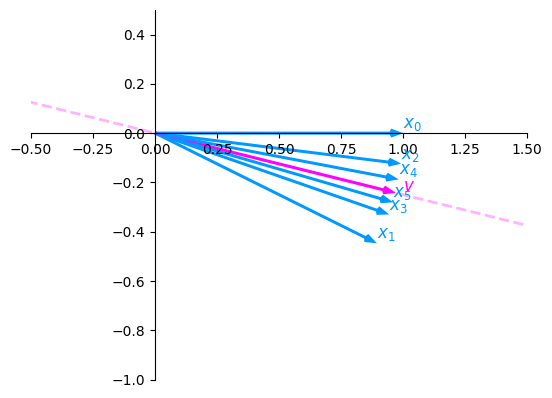

In [5]:
%matplotlib inline

from IPython.display import clear_output
import time

N = 6 # number of vectors to plot

for num_vectors in range(N+1):
    clear_output(wait=True)
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-1, 0.5)

    # Move spines to center (0,0)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # # Optional: add grid
    # ax.grid(True, alpha=0.3)
    
    # Plot pink vector first
    if num_vectors >= 1:
        ax.quiver(0, 0, unit_v[0], unit_v[1], angles='xy', scale_units='xy', scale=1,
                 color=(1,0,1), width=0.006, headwidth=3, headlength=4)
        ax.text(1, -0.25, '$v$', fontsize=12, ha='left', va='bottom',color=(1,0,1))

        # Eigenspace: line beyond plot limits
        t = np.linspace(-2, 2, 100)
        ax.plot(t * 1, t * (-0.25), '--', color=(1,0,1), alpha=0.3, linewidth=2)
    
    # Then plot the blue vectors
    for i in range(min(num_vectors, N)):
        ax.quiver(0, 0, vec_list[i][0], vec_list[i][1], angles='xy', 
                 scale_units='xy', scale=1, color=(0, 0.6, 1), 
                 width=0.006, headwidth=3, headlength=4)
        ax.text(vec_list[i][0], vec_list[i][1], f'$x_{i}$', 
               fontsize=12, ha='left', va='bottom', color=(0, 0.6, 1))
    
    plt.show()
    time.sleep(0.5)

## Example 6.14

In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [7]:
A = np.array([[3,2],          
              [2,3]])

In [8]:
x0 = np.array([1,0])
vec_list = [x0]
eva_list = [np.dot(A@x0,x0)]  # eigenvalue approximation list

for i in range(1,16):
    new_vec = A@vec_list[-1]  # pick last vector in vec_list, and apply A to it
    vec_list.append(new_vec/np.sqrt(np.dot(new_vec,new_vec)))  # add new normalized vector to vec_list
    eva_list.append(np.dot(A@vec_list[-1],vec_list[-1]))       # add updated approx. for lambda   

In [9]:
for i in range(0,len(vec_list)):
    print(f"x_{i:<2} = {vec_list[i]}, and λ^({i:<2}) = {eva_list[i]}")

x_0  = [1 0], and λ^(0 ) = 3
x_1  = [0.83205029 0.5547002 ], and λ^(1 ) = 4.846153846153847
x_2  = [0.73480344 0.6782801 ], and λ^(2 ) = 4.993610223642173
x_3  = [0.71274083 0.70142748], and λ^(3 ) = 4.999744016382951
x_4  = [0.70823725 0.70597451], and λ^(4 ) = 4.999989760026214
x_5  = [0.70733302 0.70688047], and λ^(5 ) = 4.999999590400041
x_6  = [0.70715203 0.70706152], and λ^(6 ) = 4.999999983616001
x_7  = [0.70711583 0.70709773], and λ^(7 ) = 4.99999999934464
x_8  = [0.70710859 0.70710497], and λ^(8 ) = 4.999999999973785
x_9  = [0.70710714 0.70710642], and λ^(9 ) = 4.999999999998952
x_10 = [0.70710685 0.70710671], and λ^(10) = 4.999999999999957
x_11 = [0.7071068  0.70710677], and λ^(11) = 4.999999999999999
x_12 = [0.70710678 0.70710678], and λ^(12) = 5.0
x_13 = [0.70710678 0.70710678], and λ^(13) = 5.0
x_14 = [0.70710678 0.70710678], and λ^(14) = 5.0
x_15 = [0.70710678 0.70710678], and λ^(15) = 5.0


## Visualization

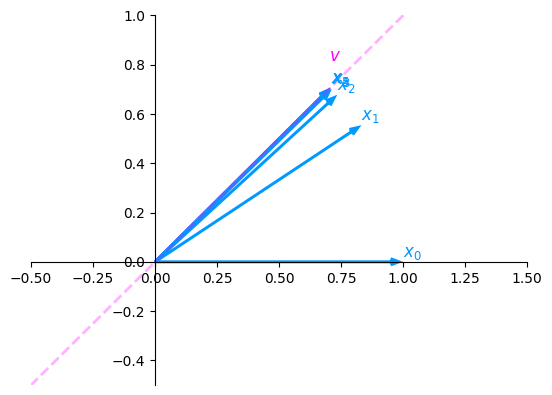

In [10]:
%matplotlib inline

v = np.array([1,1]) # eigenvector corresponding to eigenvalue 5
unit_v = v/np.sqrt(np.dot(v,v))

from IPython.display import clear_output
import time

N = 6 # number of vectors to plot

for num_vectors in range(N+1):
    clear_output(wait=True)
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1)

    # Move spines to center (0,0)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # # Optional: add grid
    # ax.grid(True, alpha=0.3)
    
    # Plot red vector first
    if num_vectors >= 1:
        ax.quiver(0, 0, unit_v[0], unit_v[1], angles='xy', scale_units='xy', scale=1,
                 color=(1,0,1), width=0.006, headwidth=3, headlength=4)
        ax.text(0.7, 0.8, '$v$', fontsize=12, ha='left', va='bottom',color=(1,0,1))

        # Eigenspace: line beyond plot limits
        t = np.linspace(-2, 2, 100)
        ax.plot(t * 1, t * 1, '--', color=(1,0,1), alpha=0.3, linewidth=2)
    
    # Then plot the blue vectors
    for i in range(min(num_vectors, N)):
        ax.quiver(0, 0, vec_list[i][0], vec_list[i][1], angles='xy', 
                 scale_units='xy', scale=1, color=(0, 0.6, 1), 
                 width=0.006, headwidth=3, headlength=4)
        ax.text(vec_list[i][0], vec_list[i][1], f'$x_{i}$', 
               fontsize=12, ha='left', va='bottom', color=(0, 0.6, 1))
    
    plt.show()
    time.sleep(0.5)